In [1]:
import numpy as np
import sys
sys.path.append("../../")
sys.path.append("../../Visualization/")
sys.path.append("../../../")

In [2]:
sys.path.append(".")

In [3]:
sys.path.append('../../periodic_patches/'); sys.path.append('../'); sys.path.append('../../../gmsh')
import inflation, sparse_matrices, mesh, numpy as np, importlib, pickle
import inflatables_parametrization as parametrization
from numpy.linalg import norm
from io_redirection import suppress_stdout
import visualization

In [4]:
import visualize_stiffness, importlib
importlib.reload(visualize_stiffness)

<module 'visualize_stiffness' from '/Users/yren/Develop/Inflatables/python/periodic_patches/experiments/parametrization_experiments/../../Visualization/visualize_stiffness.py'>

In [5]:
sys.path.append('periodic_patches/')
sys.path.append('gmsh')

In [6]:
import parametrization_experiment_helper, importlib
importlib.reload(parametrization_experiment_helper)

<module 'parametrization_experiment_helper' from '/Users/yren/Develop/Inflatables/python/periodic_patches/experiments/parametrization_experiments/parametrization_experiment_helper.py'>

In [11]:
pattern = parametrization_experiment_helper.Pattern_data[2]

In [12]:
experiment_file = pattern['experiment_file']
stiffness_path = pattern['stiffness_path']
pattern_name = pattern['name']
num_pattern_params = pattern['num_pattern_params']
param_index = pattern['param_index']
default_param = pattern['default_param']
param_range = pattern['param_range']
param_normalization_factor = pattern['param_normalization_factor']
fusing_curve_polyline = pattern['fusing_curve_polyline_function']
                                

In [13]:
# parametrization_experiment_helper.Shape_data

In [14]:
shape = parametrization_experiment_helper.Shape_data[4]

In [15]:
shape_name = shape['name']
shape_path = shape['path']

In [16]:
shape_name, pattern_name

('cashew_planar_coarse', 'square_with_ellipse_hole_angle_width_height')

### Overview

In [17]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np
import visualize_stiffness

In [18]:
with open(experiment_file, 'r') as fp:
    data = json.load(fp)

In [19]:
df = pd.DataFrame(data['data'])
valid_tags = np.array(df['name'][df['Planar equilibrium'] == 1])

In [20]:
kappa_path = None

In [21]:
bending_stiffness_data, stretching_stiffness_data, scale_factor_data, used_tags = visualize_stiffness.plot_all_data(kappa_path, stiffness_path, pattern_name, valid_tags, plot_data = False)

In [22]:
parameters = []
for index in param_index:
    parameters.append(data['pattern_parameters'][index]['values'])

In [23]:
max_bending_stiffness = np.max(bending_stiffness_data, axis = 1)
min_bending_stiffness = np.min(bending_stiffness_data, axis = 1)
max_stretching_stiffness = np.max(stretching_stiffness_data, axis = 1)
min_stretching_stiffness = np.min(stretching_stiffness_data, axis = 1)

In [24]:
x_scale_factors, y_scale_factors = visualize_stiffness.get_axis_scale_factors(stiffness_path, pattern_name, valid_tags)

In [25]:
min_scale_factors = np.min(np.concatenate((x_scale_factors.reshape(-1, 1), y_scale_factors.reshape(-1, 1)), axis = 1), axis = 1)
max_scale_factors = np.max(np.concatenate((x_scale_factors.reshape(-1, 1), y_scale_factors.reshape(-1, 1)), axis = 1), axis = 1)

In [26]:
angle_offsets = visualize_stiffness.get_max_flattening_factor_offset(stiffness_path, pattern_name, valid_tags)

### Get scale function convex hull

In [27]:
import matplotlib.cm as cm
import matplotlib as mpl

In [28]:
from scipy.spatial import ConvexHull, convex_hull_plot_2d
import numpy as np
rng = np.random.default_rng()
points = rng.random((30, 2))   # 30 random points in 2-D
# points = np.concatenate((min_scale_factor.reshape((-1, 1)), max_scale_factor.reshape((-1, 1))), axis = 1)

points = np.concatenate((max_scale_factors.reshape((-1, 1)), min_scale_factors.reshape((-1, 1))), axis = 1)
hull = ConvexHull(points)

### Validate the max and min scale factors are aligned with the x and y axis

In [29]:
import parametrization_helper

In [30]:
eqns = hull.equations

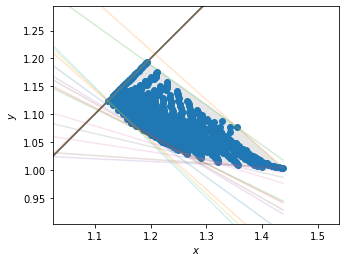

In [31]:
parametrization_helper.visualize_scale_factors(eqns, max_scale_factors, min_scale_factors)

### Generate data without augmenting

In [32]:
stiffness_coefficients = np.array(visualize_stiffness.get_stiffness_coefficients(stiffness_path, pattern_name, (used_tags)))
# For patches with reflection symmetry:
stiffness_coefficients[:, 1] *= 0
stiffness_coefficients[:, 2] *= 0

In [33]:
grid_shape = np.zeros(len(parameters) + 1, dtype = np.int64)
grid_shape[0] = 9
for i in range(len(parameters)):
    grid_shape[i + 1] = len(parameters[i])

In [34]:
grid_shape

array([ 9, 14,  9,  6])

In [35]:
grid_data = np.zeros(tuple(grid_shape))

In [36]:
stiffness_coefficients.reshape([*grid_shape[1:], 5]).shape

(14, 9, 6, 5)

In [37]:
# np.transpose(grid_stiffness_coefficients, (len(grid_stiffness_coefficients.shape)-1,) + tuple(range(len(grid_stiffness_coefficients.shape)-1)))[0]

In [38]:
grid_stiffness_coefficients = stiffness_coefficients.reshape([*grid_shape[1:], 5])
grid_stiffness_coefficients = np.transpose(grid_stiffness_coefficients, (len(grid_stiffness_coefficients.shape)-1,) + tuple(range(len(grid_stiffness_coefficients.shape)-1)))


In [39]:
grid_data[0] = max_scale_factors.reshape(grid_shape[1:])
grid_data[1] = min_scale_factors.reshape(grid_shape[1:])
grid_data[2] = x_scale_factors.reshape(grid_shape[1:])
grid_data[3] = y_scale_factors.reshape(grid_shape[1:])
grid_stiffness_coefficients = stiffness_coefficients.reshape([*grid_shape[1:], 5])
grid_stiffness_coefficients = np.transpose(grid_stiffness_coefficients, (len(grid_stiffness_coefficients.shape)-1,) + tuple(range(len(grid_stiffness_coefficients.shape)-1)))
for s in range(5):
    grid_data[4 + s] = grid_stiffness_coefficients[s]

In [40]:
importlib.reload(parametrization_helper)

<module 'parametrization_helper' from '/Users/yren/Develop/Inflatables/python/periodic_patches/experiments/parametrization_experiments/../../parametrization_helper.py'>

In [41]:
grid_data.shape

(9, 14, 9, 6)

In [42]:
if len(parameters) == 1:
    splines = parametrization_helper.scipy_get_mat_params_over_one_pattern_params_grid_interpolation(parameters, grid_data)
elif len(parameters) == 2:
    splines = parametrization_helper.scipy_get_mat_params_over_pattern_params_grid_interpolation(parameters[0], parameters[1], grid_data)
else:
    splines = parametrization_helper.ndsplines_get_mat_params_over_pattern_params_grid_interpolation(grid_data, *parameters)


In [43]:
param_range

[[6, 45], [0.2, 0.9], [1.3, 1.8]]

NameError: name 'test_parameters_z' is not defined

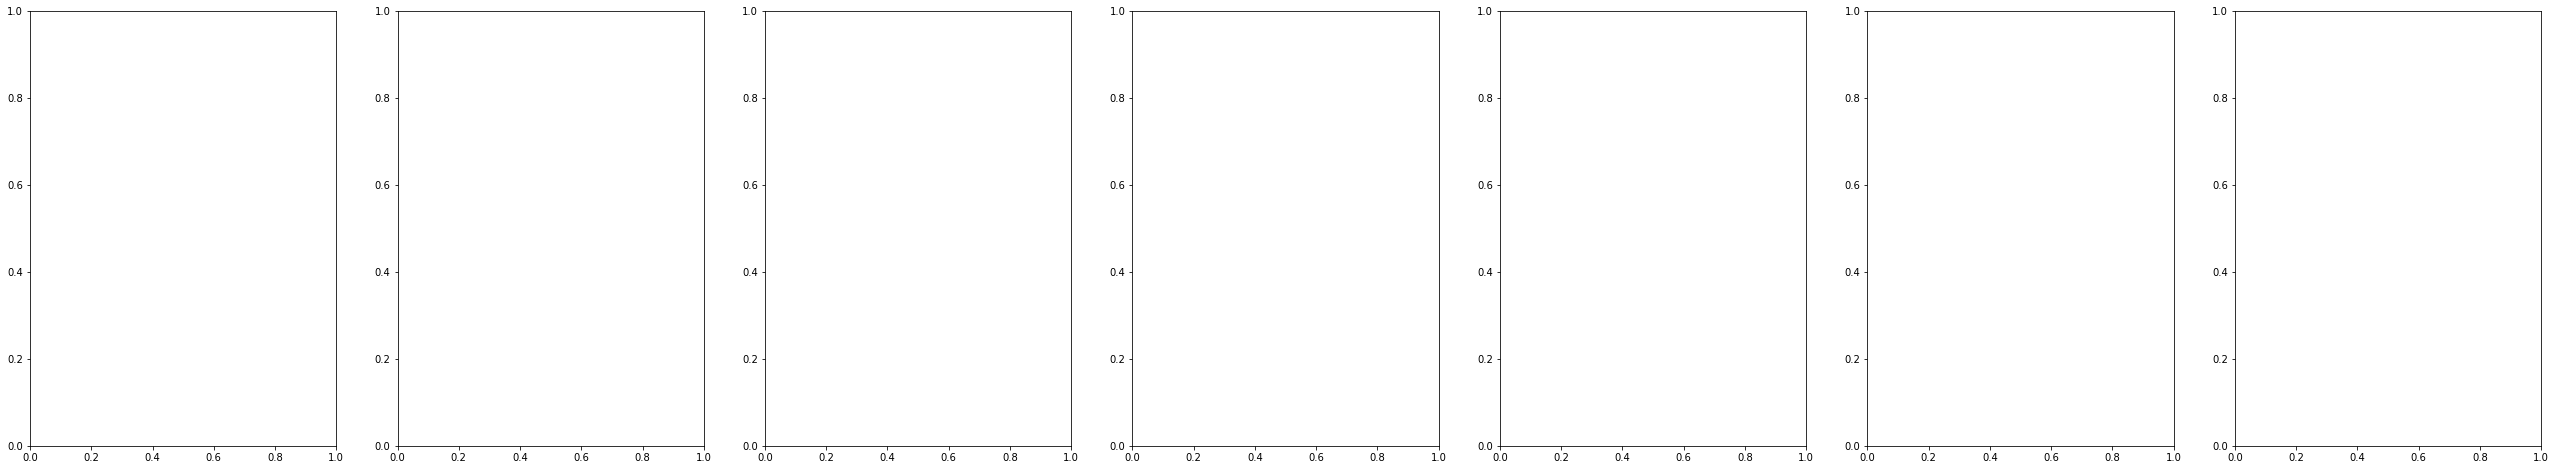

In [44]:
import numpy as np

# Generate 2D test parameters
x = np.linspace(0.6, 2.2, 100)
y = np.linspace(45, 75, 100)
test_parameters_x, test_parameters_y = np.meshgrid(x, y)

titles = ['max scale factors', 'min scale factors', 'x scale factors', 'y scale factors', 's1', 's2', 's3', 's4', 's5']
fig, axes = plt.subplots(1, 7, figsize=(45, 8))
index = [0, 1, 2, 3, 4, 7, 8]

for i in range(len(index)):
    
    # Evaluate the spline at the 2D test parameters
    z = splines[index[i] * 3 + 0]([test_parameters_x.flatten(), test_parameters_y.flatten(), test_parameters_z.flatten()])
    z = z.reshape((100, 100))

    # Use imshow to visualize the 2D data
    im = axes[i].imshow(z, extent=[0.6, 2.2, 45, 75], origin='lower', aspect='auto', cmap='coolwarm')
    axes[i].set_title(titles[index[i]], fontsize=21)

    # Add a colorbar to each subplot
    fig.colorbar(im, ax=axes[i])

In [ ]:
# import numpy as np

# # Generate 2D test parameters
# x = np.linspace(6, 45, 1)
# y = np.linspace(0.1, 0.9, 100)
# z = np.linspace(1.3, 1.8, 100)
# test_parameters_x, test_parameters_y, test_parameters_z = np.meshgrid(x, y, z)

# titles = ['max scale factors', 'min scale factors', 'x scale factors', 'y scale factors', 's1', 's2', 's3', 's4', 's5']
# fig, axes = plt.subplots(1, 7, figsize=(45, 8))
# index = [0, 1, 2, 3, 4, 7, 8]

# for i in range(len(index)):
    
#     # Evaluate the spline at the 2D test parameters
#     z = splines[index[i] * 3 + 0]([test_parameters_x.flatten(), test_parameters_y.flatten(), test_parameters_z.flatten()])
#     z = z.reshape((100, 100))

#     # Use imshow to visualize the 2D data
#     im = axes[i].imshow(z, extent=[6, 45, 0.1, 0.9], origin='lower', aspect='auto', cmap='coolwarm')
#     axes[i].set_title(titles[index[i]], fontsize=21)

#     # Add a colorbar to each subplot
#     fig.colorbar(im, ax=axes[i])

### Parametrization

In [ ]:
from periodic_simulation_setup import *

In [209]:
from py_newton_optimizer import NewtonOptimizerOptions

In [210]:
import MeshFEM, parallelism, benchmark, utils
parallelism.set_max_num_tbb_threads(32)
parallelism.set_gradient_assembly_num_threads(32)
parallelism.set_hessian_assembly_num_threads(32)

In [211]:
import utils, mesh_utilities
importlib.reload(utils)

In [212]:
target_surf = mesh.Mesh(shape_path)
target_surf.setVertices(utils.prototypeScaleNormalization(target_surf.vertices(), placeAtopFloor=False))
target_surf = mesh_utilities.subdivide_loop(target_surf, 0)

In [213]:
lines = np.array(eqns)

In [214]:
# Run some iterations of the local-global algorithm to ensure a good separation between singular values.
# This step can also be used as a prediction of the feasiblity of a design surface:
# if it is unable to nearly satisfy the singular value constraints,
# the surface is probably infeasible.
lg_21 = parametrization.LocalGlobalParametrizer(target_surf, parametrization.lscm(target_surf))

lg_21.alphaMin = 1.4
lg_21.alphaMax = np.pi / 2
print(lg_21.energy())
for i in range(1000): lg_21.runIteration()

print(lg_21.energy())
lg_21.runIteration()
print(lg_21.energy())

In [215]:
visualization.visualize(lg_21)

In [216]:
new_lines = np.array([[0, 1, -1.05], [1, 0, -np.pi / 2.], [0, -1, 0.95], [-1., 0, 1.4]])
             # , [0, -1, -1.1], [1, 0, -1.4], [-1, 0, np.pi / 2]]

In [217]:
parametrization_helper.visualize_scale_factors(new_lines, lg_21.getAlphas(), np.ones(len(lg_21.getAlphas())), )

In [218]:
lg = parametrization.LocalGlobalGenericParametrizer(target_surf, parametrization.lscm(target_surf))

lg.alphaMin = 1.4
lg.alphaMax = np.pi / 2

lg.betaMin = 1.0
lg.betaMax = 1.0

print(lg.energy())
for i in range(1000): lg.runIteration()

print(lg.energy())
lg.runIteration()
print(lg.energy())

In [219]:
importlib.reload(visualization)
visualization.visualize_both(lg)

### New local global with convex hull

In [220]:
lg = parametrization.LocalGlobalGenericParametrizer(target_surf, parametrization.lscm(target_surf))

lg.setLines(eqns)

lg.alphaMin = hull.min_bound[0]
lg.alphaMax = hull.max_bound[0]

lg.betaMin = hull.min_bound[1]
lg.betaMax = hull.max_bound[1]

print(lg.energy())
for i in range(2000): lg.runIteration()

print(lg.energy())
lg.runIteration()
print(lg.energy())

In [221]:
lg.alphaMin, lg.alphaMax, lg.betaMin, lg.betaMax

In [222]:
importlib.reload(visualization)
visualization.visualize_both(lg, show_main = True)

In [223]:
parametrization_helper.visualize_scale_factors(eqns, lg.getAlphas(), lg.getBetas())

### Pattern parameters optimization

In [224]:
default_pattern_params = []
for i in range(len(parameters)):
    default_pattern_params += [default_param[i]]  * len(lg.getAlphas())

In [225]:
rparam = parametrization.RegularizedPatternParametrizer(lg, splines, default_pattern_params, len(grid_data.shape) - 1)
rparam.patternParamBounds = np.array(param_range)
rparam.diffRegW = 0.0

In [226]:
visualization.visualize_both(rparam, height = 4)

In [227]:
PET = parametrization.RegularizedPatternParametrizer.PatternEnergyType

In [228]:
import parametrization_optimization_helper
importlib.reload(parametrization_optimization_helper)

In [229]:
rparam.bendRegW = 1

In [230]:
rparam.energy(PET.RGP)

In [231]:
rparam.energy(PET.Bending)

In [232]:
parametrization_optimization_helper.initialize_pattern_parameters(rparam, lines, num_pattern_params)

In [233]:
phiRegW, _ = parametrization_optimization_helper.add_phi_regularization(rparam, lines, num_pattern_params)

In [234]:
patternRegW, _ = parametrization_optimization_helper.add_pattern_regularization(rparam, lines, num_pattern_params, phiRegW)

### Bending

In [235]:
bendRegW, _ = parametrization_optimization_helper.add_bending_energy(rparam, lines, num_pattern_params, phiRegW, patternRegW)

In [236]:
import serialization_helper
importlib.reload(serialization_helper)

In [237]:
serialization_helper.save_parametrization_classes(target_surf, parametrization.lscm(target_surf), lg, splines, default_pattern_params, num_pattern_params, rparam, "final_parametrization.pkl.gz")

In [238]:
loaded_rparam, lg = serialization_helper.load_parametrization_classes('final_parametrization.pkl.gz')

In [239]:
names = ["Full", "PReg", "Bend", "Fitt", "SReg", "PhiR"]

energy_values = list(map(loaded_rparam.energy, [PET.Full, PET.PatternRegularization, PET.Bending, PET.DEBUG_Fitting, PET.DEBUG_StretchRegularization, PET.DEBUG_PhiRegularization]))
print("After: ", list(zip(names, energy_values)))

## Upsampling and channel generation

In [240]:
import parametrization_helper
importlib.reload(parametrization_helper)
import visualization

In [241]:
import time
time_stamp = time.strftime("%Y_%m_%d_%H_%M")
print(time_stamp)

In [242]:
import os

In [243]:
# time_stamp = '2024_01_15_15_58'

In [244]:
data_path = "{}_{}/{}".format(shape_name, pattern_name, time_stamp)
if not os.path.exists(data_path):
    os.makedirs(data_path)  
    

In [245]:
default_param

In [246]:
fusing_lines = fusing_curve_polyline(default_param)[0].reshape(-1, 2)
fusing_edges = [[i, i + 1] for i in range(len(fusing_lines) - 1)]

In [247]:
boundary_vertices = [[0, 0], [np.pi, 0], [np.pi, np.pi], [0, np.pi]]

In [248]:
boundary_edges = np.array([[0, 1], [1, 2], [2, 3], [3, 0]]) + len(fusing_lines)

In [249]:
visualization.plot_line_segments(list(fusing_lines) + boundary_vertices, fusing_edges + list(boundary_edges))

In [275]:
default_frequency = 0.4
default_mesh_size = 4
default_edge_soup_threshold = 1e0

scale = 1

frequency = default_frequency * scale
mesh_size = default_mesh_size / scale
edge_soup_threshold = default_edge_soup_threshold


In [276]:
# sdfVertices, sdfTris, sdf, sheet_vxs, concatenated_polylines, sheet_edges_polylines,  boundaryVxs, boundaryEdges, upsampleMesh_vertices, upsampleMesh_triangles, upsampledAngles, upsampledPatternParams = parametrization_helper.get_polyline_from_pattern_parameters(_, fusing_curve_polyline, nsubdiv = 4, frequency=0.2, duplicates_removable_threshold=[1e-4, 1e-2, 1e-1, 1e0, 2e0], path = data_path, load_data = 'param')

In [277]:
sdfVertices, sdfTris, sdf, sheet_vxs, concatenated_polylines, sheet_edges_polylines,  boundaryVxs, boundaryEdges, upsampleMesh_vertices, upsampleMesh_triangles, upsampledAngles, upsampledPatternParams = parametrization_helper.get_polyline_from_pattern_parameters(rparam, fusing_curve_polyline, nsubdiv = 4, frequency=default_frequency, duplicates_removable_threshold=[1e-4, 1e-2, 1e-1, 1e0, 2e0, 3e0], path = data_path)

In [278]:
if len(boundaryEdges) > 1:
    concatenated_boundary_edges = []
    for polyline in boundaryEdges:
        concatenated_boundary_edges.extend(polyline)
    concatenated_boundary_edges = np.array(concatenated_boundary_edges)
    # Define a function to calculate the length of a sublist
    def sublist_length(sublist):
        return len(sublist)

    # Sort boundaryEdges in descending order of sublist length
    boundaryEdges = sorted(boundaryEdges, key=sublist_length, reverse=True)
else:
    concatenated_boundary_edges = np.array(boundaryEdges[0])


In [279]:
visualization.scalarFieldPlotFast(sdfVertices, sdfTris, sdf, width = 5, height=5)
visualization.plot_line_segments(sheet_vxs, concatenated_polylines, width = 5, height = 5)
visualization.plot_line_segments(list(sheet_vxs) + list(boundaryVxs), list(concatenated_polylines) + list(concatenated_boundary_edges + len(sheet_vxs)), width = 15, height = 15)
plt.scatter(boundaryVxs[concatenated_boundary_edges[:,0], 0], boundaryVxs[concatenated_boundary_edges[:,0], 1], c = np.arange(len(concatenated_boundary_edges[:, 0])), cmap = mpl.colormaps['Greys'])

## Meshing and inflation simulation

In [280]:
import mesher_helper
importlib.reload(mesher_helper)

In [281]:
import time
time_stamp = time.strftime("%Y_%m_%d_%H_%M")

In [282]:
importlib.reload(parametrization_helper)

In [283]:
default_frequency = 0.2
default_mesh_size = 2
default_edge_soup_threshold = 2e0

scale = 1

frequency = default_frequency * scale
# mesh_size = default_mesh_size / scale
edge_soup_threshold = default_edge_soup_threshold

if use_holes:
    boundary_holes_vxs, non_boundary_holes_vxs, boundary_polygons = parametrization_helper.post_process_holes(boundaryVxs, boundaryEdges, sheet_vxs, sheet_edges_polylines, smoothing = 5.0, area_threshold=(default_mesh_size / 2) **2, avg_len = default_mesh_size / 2, distance_threshod=default_mesh_size / 2)
else:
    selected_elements = [np.array(sublist)[:, 0] for sublist in boundaryEdges[1:]]
    non_boundary_holes_vxs = list(boundaryVxs[selected_elements])

boundary_curve = boundaryVxs[np.array(boundaryEdges[0])[:, 0]]
boundary_curve = parametrization_helper.smooth_polyline(boundary_curve, 0, default_mesh_size)[:-1]

if use_holes:
    v, f, fusing_data = mesher_helper.generate_mesh_non_periodic(default_mesh_size, boundary_curve, [], non_boundary_holes_vxs, [], [], gui = False)
else:
    v, f, fusing_data = mesher_helper.generate_mesh_non_periodic(default_mesh_size, boundary_curve, [], non_boundary_holes_vxs, sheet_vxs, concatenated_polylines, gui = False)

In [284]:
import copy
# Use the function
new_v, new_f, new_fusing_without_boundary = parametrization_helper.remove_dangling_vertices(v, f - 1, fusing_data)
m = MeshFEM.mesh.Mesh(new_v, new_f)
new_fusing = copy.copy(new_fusing_without_boundary)
new_fusing[m.boundaryVertices()] = True

fusing_data = new_fusing

In [285]:
# m, iwv, iwbv = sheet_meshing.newMeshingAlgorithm(sdfVertices, sdfTris, sdf, SV, SE, triArea=1e0)


In [286]:
visualization.plot_2d_mesh(m, pointList=np.where(np.array(new_fusing) == 1)[0], width=10, height=10)


In [287]:
import inflation
isheet = inflation.InflatableSheet(m, new_fusing)

### Save pattern

In [288]:
import shapely
channelMargin = 11

In [219]:
V = m.vertices()
polylines = isheet.fusedRegionBooleanIntersectSheetBoundary()
shapely_boundaryEdges = shapely.MultiLineString([V[p] for p in polylines])
#utils.save(boundaryEdges.buffer(channelMargin), 'test.pkl.gz')
bypasses = shapely_boundaryEdges.buffer(channelMargin)
if bypasses.geom_type == 'Polygon': bypasses = [bypasses] # we generally expect a multipolygon...
outerAirChannelPolygons = [shapely.ops.unary_union([shapely.Polygon(boundaryVxs[np.array(boundaryEdges[0])[:, 0]])] + list(bypasses.geoms))]

In [220]:
smart_polygon = outerAirChannelPolygons[0]

In [221]:
coords = np.array(smart_polygon.exterior.coords)

In [222]:
len(coords)

In [223]:
np.concatenate((coords[:-1], np.zeros((len(coords)-1, 1))), axis = 1)

In [224]:
plt.scatter(coords[:, 0], coords[:, 1])

In [225]:
polylines = []
for polyline in sheet_edges_polylines:
    polyline = np.array(polyline)
    polylines.append(sheet_vxs[np.array(list(polyline[:, 0]) + list([polyline[-1, 1]]))][:, :2].tolist())
parametrization_helper.save_to_obj(coords[:-1], polylines, '{}_{}_sheet_pattern_{}_margin_{}.obj'.format(shape_name, pattern_name, time_stamp, channelMargin))

### End

In [300]:
if not 'rparam' in globals():
    uv = np.load(data_path + '/rparam_uv.npy')
else:
    uv = rparam.uv()

In [301]:
from mesh_utilities import SurfaceSampler, tubeRemesh


paramSampler = SurfaceSampler(np.pad(uv, [(0, 0), (0, 1)], 'constant'), target_surf.triangles())
liftedSheetPositions = paramSampler.sample(m.vertices(), target_surf.vertices())

isheet.setUninflatedDeformation(liftedSheetPositions.transpose())

isheet.getVars()

In [302]:
import py_newton_optimizer
niter = 2000
iterations_per_output = 10
opts = py_newton_optimizer.NewtonOptimizerOptions()
opts.useIdentityMetric = True
opts.beta = 1e-4
opts.gradTol = 1e-10
opts.niter = iterations_per_output

In [303]:
# Are the flat region causing a problem? They might not actually control the metric...
# Try replacing them with single wall...
# Analyze the actual stretching factor (much easier to do with skeleton walls)

from tri_mesh_viewer import TriMeshViewer
viewer = TriMeshViewer(isheet, width=768, height=640)
viewer.showWireframe(True)

viewer.show()

In [304]:
viewer.update(scalarField=utils.getStrains(isheet)[:, 0])    

In [305]:
import boundaries
bdryVars = boundaries.getOuterBoundaryVars(isheet)
fixedVars = bdryVars

In [309]:
isheet.setUseTensionFieldEnergy(True)

isheet.setUseHessianProjectedEnergy(False)

fixedVars, hessianShift = bdryVars, 1e-6

framerate = 20
def cb(it):
    if it % framerate == 0:
        viewer.update(scalarField=utils.getStrains(isheet)[:, 0])    

### First solve with low pressure to get out of indefinite state

In [310]:
isheet.pressure = 1e-5

In [311]:
opts.niter = 5

import time
cr = inflation.inflation_newton(isheet, fixedVars, opts, hessianShift = hessianShift, callback = cb)

### Then inflate

In [312]:
isheet.pressure = 5e-1

In [313]:
opts.niter = 2000
opts.gradTol = 1e-7

import time
benchmark.reset()
cr = inflation.inflation_newton(isheet, fixedVars, opts, hessianShift = hessianShift, callback = cb)
benchmark.report()

isheet.tensionStateHistogram()

In [237]:
def export_top_bottom_mesh(isheet, export_path, shape_name, pattern_name):
    mesh_3d = isheet.visualizationMesh(True)
    mesh_2d = isheet.mesh()
    vx_3d = mesh_3d.vertices()
    elements_3d = mesh_3d.elements()

    new_mesh_3d = MeshFEM.Mesh(vx_3d[:mesh_2d.numVertices()], elements_3d[:mesh_2d.numElements()])

    new_mesh_3d.save(export_path + '{}_{}_mesh_3d_top.obj'.format(shape_name, pattern_name))

    new_mesh_3d = MeshFEM.Mesh(vx_3d[m.numVertices():], elements_3d[mesh_2d.numElements():] - mesh_2d.numVertices())
    new_mesh_3d.save(export_path + '{}_{}_mesh_3d_bottom.obj'.format(shape_name, pattern_name))

In [238]:
export_top_bottom_mesh(isheet, data_path, shape_name, pattern_name)

In [ ]:
# isheet.nu
# for i in range(len(isheet.mesh().vertices())):
#     if (isheet.varIdx(0, i) !=  isheet.varIdx(1, i)):
#         print(isheet.varIdx(0, i), isheet.varIdx(1, i))

In [ ]:
# Plot maximum tensile strains in the sheet to verify the pressure is reasonable
from matplotlib import pyplot as plt
plt.hist(utils.getStrains(isheet)[:, 0], bins=1000);
plt.xlim(-0.04, 0.1);

### Analyze curvature of the inflated surface

In [ ]:
isa = inflation.InflatedSurfaceAnalysis(isheet)
curvature = isa.curvature()
metric = isa.metric()

In [ ]:
import matplotlib, vis
from tri_mesh_viewer import TriMeshViewer
isurf = isa.inflatedSurface()
metric_vf = vis.fields.VectorField(isurf, metric.sigma_2[:, None] * metric.left_stretch, vmin=0, vmax=1.0,
                                   align=vis.fields.VectorAlignment.CENTER, colormap=matplotlib.cm.viridis,
                                   glyph=vis.fields.VectorGlyph.CYLINDER)

viewer2 = TriMeshViewer(isurf, width=768, height=640, scalarField=vis.fields.ScalarField(isurf, curvature.meanCurvature(), colormap=matplotlib.cm.coolwarm), vectorField=None)
# viewer2.showWireframe()
viewer2.show()